In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")
import gp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from pandas import DataFrame
import openpyxl
import math
# Making table for testing masses. Currently gives lots of inf values for unknown reason.
mass_hypotheses = np.linspace(.033,.179,147).tolist()
rebin = 1
# Coefficients for the polynomial from the table for unsmeared (P0 to P4)
#coefficients = [0.00032, 0.019, -0.11, 1.39, -4.33]

#Smeared Coefficients
coefficients = [0.00038,0.041,-0.27,3.49,-11.11]

    
def sigma(mass, coeffs):
    #sigma is twice the mass resolution
    return sum(c * mass**i for i, c in enumerate(coeffs))

def sigmas(masses, coeffs):
    sigma_list = []
    for mass in masses:
        sigma_list.append(sum(c * mass**i for i, c in enumerate(coeffs)))
    return sigma_list
    
def make_table(masses, coeffs):
    sigma_list = sigmas(masses, coeffs)
    ul_list = []
    epsilon_squared_list = []
    for i in range(len(masses)):
        # Print blind range for debugging
        blind_range = (masses[i] - 2*sigma_list[i], masses[i] + 2*sigma_list[i])
        print(f"Mass: {masses[i]}, Sigma: {sigma_list[i]}, Blind Range: {blind_range}")
        
        try:
            # Create the model with the current mass and blind range
            m = gp.GaussianProcessModel(
                h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'),
                #kernel = gp.kernels.WhiteKernel() + gp.kernels.RBF() * gp.kernels.DotProduct(),
                #kernel = gp.kernels.RBF(length_scale=0.016) + gp.kernels.WhiteKernel(noise_level=7e3),
                n_restarts_optimizer=5,
                ernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
                blind_range = blind_range,
                modify_histogram = gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179)
            )
            # Calculate upper limit
            upper_limit = m.upper_limit_in_blind_region()

            # Calculate epsilon squared
            integral = np.sum(m.histogram.values()[m.blind_range_indices[0]:m.blind_range_indices[1]+1])
            print(f"integral for mass {masses[i]}: {integral}")
            frad = 18048.5*(masses[i]**5) - 10140.1*(masses[i]**4) + 2148.12*(masses[i]**3) - 212.211*(masses[i]**2) + 9.59977*masses[i] - 0.104070
            fsc = 1/137
            epsilon_squared = (2 * fsc * upper_limit)/(3 * math.pi * masses[i] * frad * integral)
            
        except Exception as e:
            print(f"Error for mass {masses[i]}: {e}")
            upper_limit = float('inf')  # or a fallback value

        ul_list.append(upper_limit)
        epsilon_squared_list.append(epsilon_squared)

    return ul_list, sigma_list, epsilon_squared_list

ul1, sl, es = make_table(mass_hypotheses, coefficients)

df = DataFrame({'Mass': mass_hypotheses, 'Blind Range Size': [i*2 for i in sl], 'Upper Limit': ul1, 'Epsilon Squared': es})
df.to_csv('ul_test.csv', index=False)


Mass: 0.033, Sigma: 0.00155121454769, Blind Range: (0.029897570904620002, 0.03610242909538)


/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  war

integral for mass 0.033: 0.0
Mass: 0.034, Sigma: 0.00158420426704, Blind Range: (0.030831591465920002, 0.03716840853408)


/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings

integral for mass 0.034: 0.0
Mass: 0.035, Sigma: 0.0016172118062500003, Blind Range: (0.0317655763875, 0.038234423612500006)


...

/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


integral for mass 0.17700000000000002: 22199.0
Mass: 0.178, Sigma: 0.007652993719840001, Blind Range: (0.16269401256031998, 0.19330598743968)


/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings

integral for mass 0.178: 20553.0
Mass: 0.179, Sigma: 0.007678451794090001, Blind Range: (0.16364309641181998, 0.19435690358818)
integral for mass 0.179: 18836.0


/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/aidanhsu/Documents/gaus-proc/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  war

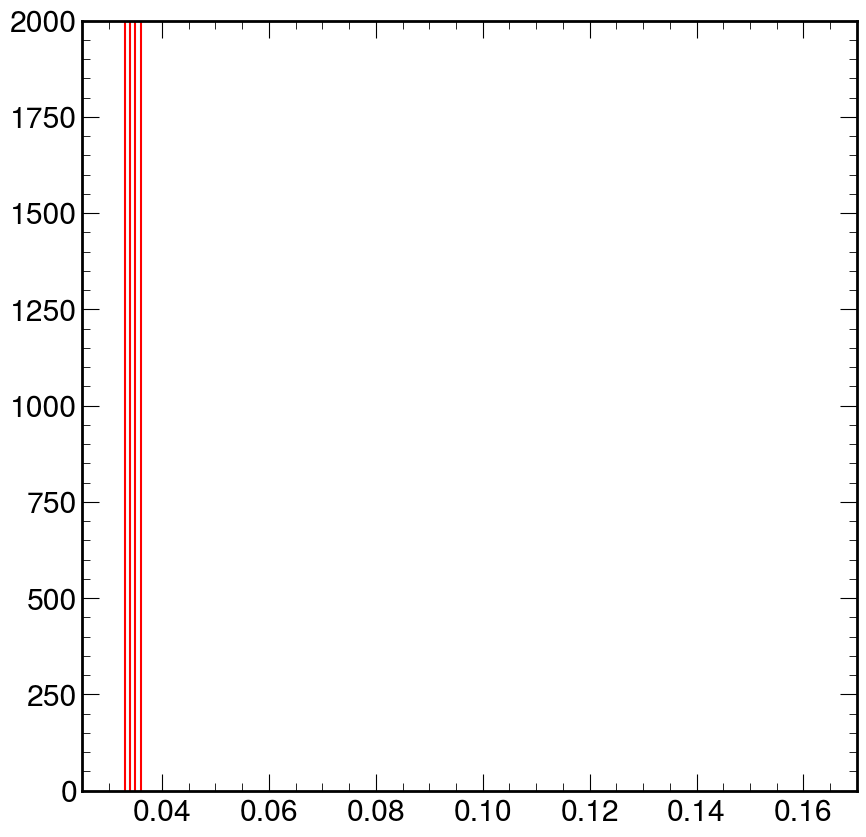

In [2]:
plot_ul = []
plot_masses = []
error_list = []
plot_es = []
for i in range(len(ul1)):
    if not (math.isinf(ul1[i]) or math.isinf(es[i])):
        plot_ul.append(ul1[i])
        plot_masses.append(mass_hypotheses[i])
        plot_es.append(es[i])
    else:
        error_list.append(mass_hypotheses[i])

plt.plot(plot_masses, plot_ul, label='Upper Limit vs Mass')
plt.vlines(error_list, 0, 8000, 'r')
ax1 = plt.gca()
ax1.set_xlim([.025, .170])
ax1.set_ylim([0, 2000])
df2 = DataFrame({'Mass': plot_masses, 'Upper Limit': plot_ul, 'Epsilon Squared': plot_es})
#df2.to_excel('ul_test_fixed.xlsx', sheet_name='sheet1', index=False)
df2.to_csv('ul_test_fixed.csv', index=False)